Préparation des données

# 1. Import

## 1.1 Import des librairies

In [990]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## 1.2 Import des fichiers

In [991]:
from google.colab import drive
drive.mount('/content/drive/')

#Importation des différents fichiers
population = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/population.csv', sep=';', encoding='latin1')
taux_import_nourriture = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Importation.denrées.alimentaires.FAO.csv', sep=';')
tarifs_douaniers = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Tarifs.douaniers.banque.modiale.csv', sep=';')
taux_inflation = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Inflation_alimentaire.csv', sep=';')
pib_par_habitant = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/PIB.par.habitant.csv', sep=';')
score_reglementaire = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Score_reglementaire.csv', sep=';')
score_logistique = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Perf.logistique.banque.mondiale.csv', sep=';', encoding='latin1')
disponibilite_alimentaire = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Disponibilite_Alimentaire.csv', sep=';')
countries_list = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/UNSD — Methodology.csv', sep=';')
distance = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/Distance.csv', sep=';')
pays_europeens = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 11/Données brutes/n-europe.csv', sep=';')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


#  2. Nettoyage des données

## 2.1 Codification des pays


Source : le site UNSD (Division statistique des Nations  Unies)  
https://unstats.un.org/unsd/methodology/m49/overview

In [992]:
countries_list.head(5)

,Global Code,Global Name,Region Code,Region Name,Sub-region Code,Sub-region Name,Intermediate Region Code,Intermediate Region Name,Country or Area,M49 Code,ISO-alpha2 Code,ISO-alpha3 Code,Least Developed Countries (LDC),Land Locked Developing Countries (LLDC),Small Island Developing States (SIDS)
0,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Algeria,12,DZ,DZA,NaN,NaN,NaN
1,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Egypt,818,EG,EGY,NaN,NaN,NaN
2,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Libya,434,LY,LBY,NaN,NaN,NaN
3,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Morocco,504,MA,MAR,NaN,NaN,NaN
4,1,World,2.0,Africa,15.0,Northern Africa,NaN,NaN,Sudan,729,SD,SDN,x,NaN,NaN


In [993]:
countries_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Global Code                              248 non-null    int64  
 1   Global Name                              248 non-null    object 
 2   Region Code                              247 non-null    float64
 3   Region Name                              247 non-null    object 
 4   Sub-region Code                          247 non-null    float64
 5   Sub-region Name                          247 non-null    object 
 6   Intermediate Region Code                 105 non-null    float64
 7   Intermediate Region Name                 105 non-null    object 
 8   Country or Area                          248 non-null    object 
 9   M49 Code                                 248 non-null    int64  
 10  ISO-alpha2 Code                          247 non-n

In [994]:
# Je supprime les colonnes inutiles, je renomme les colonnes pour assurer la cohérence avec l'ensemble des jeux de données
colonnes_a_garder = ['M49 Code', 'ISO-alpha3 Code', 'ISO-alpha2 Code', 'Country or Area', 'Region Name', 'Sub-region Name', 'Intermediate Region Name']
countries_list = countries_list[colonnes_a_garder]
countries_list.rename(columns={'Country or Area': 'Country Name', 'ISO-alpha3 Code': 'Country Code', 'M49 Code' : 'Code zone (M49)'}, inplace=True)
countries_list.head()
countries_list.head(10)

,Code zone (M49),Country Code,ISO-alpha2 Code,Country Name,Region Name,Sub-region Name,Intermediate Region Name
0,12,DZA,DZ,Algeria,Africa,Northern Africa,NaN
1,818,EGY,EG,Egypt,Africa,Northern Africa,NaN
2,434,LBY,LY,Libya,Africa,Northern Africa,NaN
3,504,MAR,MA,Morocco,Africa,Northern Africa,NaN
4,729,SDN,SD,Sudan,Africa,Northern Africa,NaN
5,788,TUN,TN,Tunisia,Africa,Northern Africa,NaN
6,732,ESH,EH,Western Sahara,Africa,Northern Africa,NaN
7,86,IOT,IO,British Indian Ocean Territory,Africa,Sub-Saharan Africa,Eastern Africa
8,108,BDI,BI,Burundi,Africa,Sub-Saharan Africa,Eastern Africa
9,174,COM,KM,Comoros,Africa,Sub-Saharan Africa,Eastern Africa


In [995]:
# Je vérifie les doublons
countries_list[countries_list['Country Code'].duplicated(keep=False)]

,Code zone (M49),Country Code,ISO-alpha2 Code,Country Name,Region Name,Sub-region Name,Intermediate Region Name


## 2.2 Population

Source : La Banque mondiale  
https://donnees.banquemondiale.org/indicateur/SP.POP.TOTL

In [996]:
population.head(15)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Column1
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,NaN,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,NaN,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN
5,Albanie,ALB,"Population, total",SP.POP.TOTL,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,...,2876101.0,2873457.0,2866376.0,2854191.0,2837849.0,2811666.0,2777689.0,2745972.0,2714617.0,NaN
6,Andorre,AND,"Population, total",SP.POP.TOTL,9510.0,10283.0,11086.0,11915.0,12764.0,13634.0,...,72181.0,73763.0,75162.0,76474.0,77380.0,78364.0,79705.0,80856.0,81938.0,NaN
7,Le monde arabe,ARB,"Population, total",SP.POP.TOTL,91540853.0,93931683.0,96428599.0,99038509.0,101729760.0,104494008.0,...,419808341.0,428315886.0,435998060.0,444281315.0,453723239.0,460646603.0,471352066.0,482105978.0,492579811.0,NaN
8,Émirats arabes unis,ARE,"Population, total",SP.POP.TOTL,131334.0,137989.0,144946.0,152211.0,159692.0,167103.0,...,8935095.0,9223225.0,9346701.0,9445785.0,9401038.0,9575152.0,10074977.0,10483751.0,10876981.0,NaN
9,Argentine,ARG,"Population, total",SP.POP.TOTL,20386045.0,20726276.0,21072538.0,21421705.0,21769453.0,22112629.0,...,43900313.0,44288894.0,44654882.0,44973465.0,45191965.0,45312281.0,45407904.0,45538401.0,45696159.0,NaN


In [997]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

In [998]:
population.nunique()

,0
Country Name,264
Country Code,266
Indicator Name,1
Indicator Code,1
1960,260
...,...
2021,263
2022,263
2023,263
2024,263


In [999]:
# Suppression des colonnes inutiles'
population = population.drop(columns=['Column1', 'Indicator Name', 'Indicator Code'])

In [1000]:
# Suppression des colonnes représentant les années de 1960 à 2023
# Pour supprimer les années, je crée une liste des colonnes à supprimer
years_to_drop = [str(year) for year in range(1960, 2024)]

# Je supprime toutes les années antérieures à 2024
population = population.drop(columns=years_to_drop)

# Afficher les premières lignes pour voir la structure
print("Premières lignes du DataFrame 'population' après suppression :")
population.head(5)

Premières lignes du DataFrame 'population' après suppression :


,Country Name,Country Code,2024
0,Aruba,ABW,107624.0
1,NaN,AFE,769294618.0
2,Afghanistan,AFG,42647492.0
3,NaN,AFW,521764076.0
4,Angola,AGO,37885849.0


Compter les valeurs manquantes dans le DataFrame `population`

In [1001]:
# Je cherche les valeurs nulles
population.isnull().sum()

,0
Country Name,2
Country Code,0
2024,1


In [1002]:
# Je consulte les pays dont le nom n'est pas renseigné
population[population['Country Name'].isnull()]

,Country Name,Country Code,2024
1,NaN,AFE,769294618.0
3,NaN,AFW,521764076.0


In [1003]:
# Je consulte les pays dont l'effectif de population n'est pas renseigné
population[population['2024'].isnull()]

,Country Name,Country Code,2024
110,Non classifié,INX,NaN


In [1004]:
# Je supprime les deux lignes en question
population = population.drop(population[population['Country Name'].isnull()].index)
population = population.drop(population[population['2024'].isnull()].index)
# Je renomme la colonne avec les valeurs de population et je change son type
population = population.rename(columns={'2024': 'Population'})
population['2024'] = population['Population'].astype(int)


In [1005]:
population.head(10)

,Country Name,Country Code,Population,2024
0,Aruba,ABW,107624.0,107624
2,Afghanistan,AFG,42647492.0,42647492
4,Angola,AGO,37885849.0,37885849
5,Albanie,ALB,2714617.0,2714617
6,Andorre,AND,81938.0,81938
7,Le monde arabe,ARB,492579811.0,492579811
8,Émirats arabes unis,ARE,10876981.0,10876981
9,Argentine,ARG,45696159.0,45696159
10,Arménie,ARM,3033500.0,3033500
11,Samoa américaines,ASM,46765.0,46765


In [1006]:
len(population)

263

In [1007]:
# J'affiche les lignes qui ont un code pays absent du fichier pays de l'UNSD (essentiellement des agrégats régionaux)
population[~population['Country Code'].isin(countries_list['Country Code'])]

,Country Name,Country Code,Population,2024
7,Le monde arabe,ARB,4.925798e+08,492579811
36,Europe centrale et les pays baltes,CEB,1.000501e+08,100050066
38,Îles Anglo-Normandes,CHI,1.681260e+05,168126
49,Petits états des Caraïbes,CSS,4.539060e+06,4539060
61,Asie de lEst et Pacifique (hors revenu élevé),EAP,2.141122e+09,2141122258
62,de dividende précoce démographique,EAR,3.552279e+09,3552278604
63,Asie de lEst et Pacifique,EAS,2.388378e+09,2388378491
64,Europe et Asie centrale (hors revenu élevé),ECA,2.504859e+08,250485944
65,Europe et Asie centrale,ECS,9.284657e+08,928465742
68,Zone euro,EMU,3.511258e+08,351125804


In [1008]:
# Je supprime les pays avec les codes pays non partagés avec le fichier des pays (suppression )
population = population[population['Country Code'].isin(countries_list['Country Code'])]
len(population)

215

In [1009]:
# Je vérifie les doublons
population[population['Country Code'].duplicated(keep=False)]

,Country Name,Country Code,Population,2024


## 2.3 Taux d'importation des denrées alimentaires

Source : La Banque mondiale  
https://data360.worldbank.org/en/indicator/WB_WDI_TM_VAL_FOOD_ZS_UN
  
Taux d'importation de denrées alimentaires parmi le volume total des importations de marchandises

In [1010]:
taux_import_nourriture.head(5)

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,DATA_SOURCE_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,AFW,Africa Western and Central,WB_WDI_TM_VAL_FOOD_ZS_UN,Food imports (% of merchandise imports),_T,...,World Development Indicators (WDI),RATIO,Ratio,30.00:00:00,Annual,NaN,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,EMU,Euro area,WB_WDI_TM_VAL_FOOD_ZS_UN,Food imports (% of merchandise imports),_T,...,World Development Indicators (WDI),RATIO,Ratio,30.00:00:00,Annual,NaN,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,ECS,Europe & Central Asia,WB_WDI_TM_VAL_FOOD_ZS_UN,Food imports (% of merchandise imports),_T,...,World Development Indicators (WDI),RATIO,Ratio,30.00:00:00,Annual,NaN,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,EUU,European Union,WB_WDI_TM_VAL_FOOD_ZS_UN,Food imports (% of merchandise imports),_T,...,World Development Indicators (WDI),RATIO,Ratio,30.00:00:00,Annual,NaN,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,Annual,HIC,High income,WB_WDI_TM_VAL_FOOD_ZS_UN,Food imports (% of merchandise imports),_T,...,World Development Indicators (WDI),RATIO,Ratio,30.00:00:00,Annual,NaN,A,Normal value,PU,Public


In [1011]:
taux_import_nourriture.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9906 entries, 0 to 9905
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               9906 non-null   object 
 1   STRUCTURE_ID            9906 non-null   object 
 2   ACTION                  9906 non-null   object 
 3   FREQ                    9906 non-null   object 
 4   FREQ_LABEL              9906 non-null   object 
 5   REF_AREA                9906 non-null   object 
 6   REF_AREA_LABEL          9906 non-null   object 
 7   INDICATOR               9906 non-null   object 
 8   INDICATOR_LABEL         9906 non-null   object 
 9   SEX                     9906 non-null   object 
 10  SEX_LABEL               9906 non-null   object 
 11  AGE                     9906 non-null   object 
 12  AGE_LABEL               9906 non-null   object 
 13  URBANISATION            9906 non-null   object 
 14  URBANISATION_LABEL      9906 non-null   

In [1012]:
# Je conserve uniquement les données nécessaires
colonnes_a_garder = ['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']
taux_import_nourriture = taux_import_nourriture[colonnes_a_garder]

In [1013]:
taux_import_nourriture.head(5)

,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE
0,AFW,Africa Western and Central,1962,18.032962
1,EMU,Euro area,1962,22.444318
2,ECS,Europe & Central Asia,1962,23.078828
3,EUU,European Union,1962,21.931043
4,HIC,High income,1962,22.088577


In [1014]:
# Je recherche le nombre de valeurs pour la variable TIME PERIOD, i.e le nombre d'années
taux_import_nourriture['TIME_PERIOD'].unique()

array([1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
       1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983,
       1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
       1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [1015]:
# Je recherche le nombre de valeurs par année pour chercher l'année la plus complète en terme de données
taux_import_nourriture.groupby('TIME_PERIOD')['OBS_VALUE'].count()

,OBS_VALUE
TIME_PERIOD,
1962,87
1963,91
1964,93
1965,100
1966,103
...,...
2020,202
2021,204
2022,198


In [1016]:
# Je sélectionne l'année 2023, compromis entre la complétude et l'actualité de la donnée
taux_import_nourriture = taux_import_nourriture[taux_import_nourriture['TIME_PERIOD'] == 2023]

In [1017]:
# Je renomme les colonnes pour la cohérence avec les autres jeus de données, je supprime la colonne année désormais inutile
taux_import_nourriture = taux_import_nourriture.rename(columns={'REF_AREA': 'Country Code', 'REF_AREA_LABEL': 'Country Name', 'TIME_PERIOD': 'Année', 'OBS_VALUE': 'Taux d\'importation nourriture'})
taux_import_nourriture.drop(columns=['Année'], inplace=True)
taux_import_nourriture.head(5)

,Country Code,Country Name,Taux d'importation nourriture
9592,AFE,Africa Eastern and Southern,10.605016
9593,AFW,Africa Western and Central,14.764964
9594,ARB,Arab World,11.683214
9595,CSS,Caribbean small states,16.628681
9596,CEB,Central Electricity Board (CEB),8.764036


In [1018]:
len(taux_import_nourriture)

192

In [1019]:
# J'affiche les lignes qui ont un code pays absent du fichier pays de l'UNSD
taux_import_nourriture[~taux_import_nourriture['Country Code'].isin(countries_list['Country Code'])]

,Country Code,Country Name,Taux d'importation nourriture
9592,AFE,Africa Eastern and Southern,10.605016
9593,AFW,Africa Western and Central,14.764964
9594,ARB,Arab World,11.683214
9595,CSS,Caribbean small states,16.628681
9596,CEB,Central Electricity Board (CEB),8.764036
9597,EAR,Early-demographic dividend,9.650621
9598,EAS,East Asia & Pacific,7.860635
9599,EAP,East Asia & Pacific (excluding high income),9.124623
9600,TEA,East Asia & Pacific (IDA & IBRD),9.124623
9601,EMU,Euro area,10.062027


In [1020]:
# J'enlève les ensembles régionaux ne figurant pas dans la liste de l'UNSD
taux_import_nourriture = taux_import_nourriture[taux_import_nourriture['Country Code'].isin(countries_list['Country Code'])]
len(taux_import_nourriture)

152

In [1021]:
# Je vérifie les doublons
taux_import_nourriture[taux_import_nourriture['Country Code'].duplicated(keep=False)]

,Country Code,Country Name,Taux d'importation nourriture


## 2.4 Performance logistique

Source : La Banque Mondiale  
https://data360.worldbank.org/en/indicator/WB_LPI_LP_LPI_OVRL_RK  
Score sur 5

In [1022]:
score_logistique.head(5)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Column1
0,Aruba,ABW,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.578623,NaN,2.492222,NaN,NaN,NaN,2.618182,NaN,NaN,NaN
2,Afghanistan,AFG,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.141282,NaN,1.950000,NaN,NaN,NaN,1.900000,NaN,NaN,NaN
3,NaN,AFW,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.349977,NaN,2.413333,NaN,NaN,NaN,2.473333,NaN,NaN,NaN
4,Angola,AGO,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,2.241183,NaN,2.050000,NaN,NaN,NaN,2.100000,NaN,NaN,NaN


In [1023]:
score_logistique.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [1024]:
# Je conserve les colonnes nécessaires
colonnes_a_garder_logistique = ['Country Name', 'Country Code', '2022']
score_logistique = score_logistique[colonnes_a_garder_logistique]
# Je filtre sur l'année 2022
score_logistique = score_logistique.rename(columns={'2022': 'Score logistique'})
score_logistique.head(5)

,Country Name,Country Code,Score logistique
0,Aruba,ABW,NaN
1,NaN,AFE,2.618182
2,Afghanistan,AFG,1.900000
3,NaN,AFW,2.473333
4,Angola,AGO,2.100000


In [1025]:
len(score_logistique)

266

In [1026]:
# Je regarde la liste des pays non présents dans la liste UNSD
score_logistique[~score_logistique['Country Code'].isin(countries_list['Country Code'])]

,Country Name,Country Code,Score logistique
1,NaN,AFE,2.618182
3,NaN,AFW,2.473333
7,Le monde arabe,ARB,2.793750
36,Europe centrale et les pays baltes,CEB,3.354545
38,Îles Anglo-Normandes,CHI,NaN
49,Petits états des Caraïbes,CSS,2.600000
61,Asie de lEst et Pacifique (hors revenu élevé),EAP,2.958333
62,de dividende précoce démographique,EAR,2.746512
63,Asie de lEst et Pacifique,EAS,3.300000
64,Europe et Asie centrale (hors revenu élevé),ECA,2.720000


In [1027]:
# J'enlève les pays que je ne veux pas garder
score_logistique = score_logistique[score_logistique['Country Code'].isin(countries_list['Country Code'])]
len(score_logistique)

215

In [1028]:
# Je vérifie les doublons
score_logistique[score_logistique['Country Code'].duplicated(keep=False)]

,Country Name,Country Code,Score logistique


## 2.5 Tarifs douaniers

Source : La Banque Mondiale et Eurostat (pour la spécificité du marché européen)   
https://data360.worldbank.org/en/indicator/WB_WDI_TM_TAX_TCOM_SM_FN_ZS?view=datatable&country=FRA  
https://ec.europa.eu/eurostat/statistics-explained/images/9/9f/Country_Codes_and_Names.xlsx  
Les taux tarifaires de la banque mondiale portent sur les produits primaires (produits alimentaires, les boissons et matières brutes)

In [1029]:
tarifs_douaniers.head(5)

,REF_AREA,REF_AREA_LABEL,TIME_PERIOD,OBS_VALUE
0,EUU,European Union,1988,6.90
1,FIN,Finland,1988,6.52
2,HKG,"Hong Kong SAR, China",1988,0.00
3,JPN,Japan,1988,7.65
4,KOR,"Korea, Rep.",1988,20.54


In [1030]:
tarifs_douaniers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3837 entries, 0 to 3836
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   REF_AREA        3837 non-null   object 
 1   REF_AREA_LABEL  3837 non-null   object 
 2   TIME_PERIOD     3837 non-null   int64  
 3   OBS_VALUE       3837 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 120.0+ KB


In [1031]:
# Je consulte les différentes années présentes dans le jeu de données
tarifs_douaniers['TIME_PERIOD'].unique()

array([1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [1032]:
# Je vérifie le nombre de valeurs par année pour déterminer l'année à retenir
tarifs_douaniers.groupby('TIME_PERIOD')['OBS_VALUE'].count()

,OBS_VALUE
TIME_PERIOD,
1988,11
1989,13
1990,15
1991,15
1992,20
1993,36
1994,21
1995,46
1996,70


In [1033]:
#Je sélectionne l'année 2022
tarifs_douaniers = tarifs_douaniers[tarifs_douaniers['TIME_PERIOD'] == 2022]
#Je renomme les colonnes dans un souci de cohérence avec kes autres sources
tarifs_douaniers = tarifs_douaniers.rename(columns={'REF_AREA': 'Country Code', 'REF_AREA_LABEL': 'Country Name', 'OBS_VALUE': 'Tarifs douaniers'})
#Je supprime la colonne devenue inutile
tarifs_douaniers = tarifs_douaniers.drop(columns=['TIME_PERIOD'])
tarifs_douaniers.head(5)

,Country Code,Country Name,Tarifs douaniers
3693,EUU,European Union,8.99
3694,ALB,Albania,4.75
3695,DZA,Algeria,20.74
3696,AGO,Angola,18.75
3697,ARG,Argentina,8.86


In [1034]:
len(tarifs_douaniers)

144

In [1035]:
# Je consulte les codes pays non présents dans la liste UNSD
tarifs_douaniers[~tarifs_douaniers['Country Code'].isin(countries_list['Country Code'])]

,Country Code,Country Name,Tarifs douaniers
3693,EUU,European Union,8.99


In [1036]:
# Je supprime les codes pays non désirés
tarifs_douaniers = tarifs_douaniers[tarifs_douaniers['Country Code'].isin(countries_list['Country Code'])]
len(tarifs_douaniers)

143

In [1037]:
# Je vérifie les doublons
tarifs_douaniers[tarifs_douaniers['Country Code'].duplicated(keep=False)]

,Country Code,Country Name,Tarifs douaniers


In [1038]:
pays_europeens.head(5)

,AREA,CODE,COUNTRY NAME
0,European Union (EU),EU-28,European Union (28 countries)
1,European Union (EU),BE,Belgium
2,European Union (EU),BG,Bulgaria
3,European Union (EU),CZ,Czech Republic
4,European Union (EU),DK,Denmark


En l'état, le tableau contient des données incorrectes, puisqu'il n'y a pas de barrières douanières entre pays de l'Union Européenn. Je dois donc importer la liste des pays membres de l'UE (27 états en 2025) pour porter la valeur à 0 pour ces pays.

In [1039]:
pays_europeens.head(5)

,AREA,CODE,COUNTRY NAME
0,European Union (EU),EU-28,European Union (28 countries)
1,European Union (EU),BE,Belgium
2,European Union (EU),BG,Bulgaria
3,European Union (EU),CZ,Czech Republic
4,European Union (EU),DK,Denmark


In [1040]:
# Je consulte les valeurs de la colonne AREA
pays_europeens['AREA'].unique()

array(['European Union (EU)', 'European Free Trade Association (EFTA)',
       'EU candidate countries\xa0',
       'European Neighbourhood Policy (ENP)-South',
       'Other European countries', 'Non-European countries', 'World'],
      dtype=object)

In [1041]:
# Je filtre la liste pour retenir les pays de l'UE
pays_europeens = pays_europeens[pays_europeens['AREA'] == 'European Union (EU)']
# Je supprime la première ligne qui est une agrégation
pays_europeens = pays_europeens[pays_europeens['CODE'] != 'EU-28 ']
pays_europeens = pays_europeens[pays_europeens['COUNTRY NAME'] != 'United Kingdom']
# Je supprime cette colonne devenue inutile et renommme l'autre pour la fusion à venir
pays_europeens = pays_europeens.drop(columns=['AREA'])
pays_europeens = pays_europeens.rename(columns={'CODE': 'ISO-alpha2 Code'})
pays_europeens.head(5)

,ISO-alpha2 Code,COUNTRY NAME
1,BE,Belgium
2,BG,Bulgaria
3,CZ,Czech Republic
4,DK,Denmark
5,DE,Germany (including former GDR from 1991)


In [1042]:
# Je contrôle le nombre de pays dans ma liste pour qu'il soit égal à 27
len(pays_europeens)

27

In [1043]:
countries_list.head(5)

,Code zone (M49),Country Code,ISO-alpha2 Code,Country Name,Region Name,Sub-region Name,Intermediate Region Name
0,12,DZA,DZ,Algeria,Africa,Northern Africa,NaN
1,818,EGY,EG,Egypt,Africa,Northern Africa,NaN
2,434,LBY,LY,Libya,Africa,Northern Africa,NaN
3,504,MAR,MA,Morocco,Africa,Northern Africa,NaN
4,729,SDN,SD,Sudan,Africa,Northern Africa,NaN


In [1044]:
# Je supprime des espaces dans les codes pays à lettres empêchant la fusion
pays_europeens['ISO-alpha2 Code'] = pays_europeens['ISO-alpha2 Code'].str.strip()
# Je réalise la fusion des fichiers de pays mondiaux et européens pour récupérer la codification pays à 3 lettres
merged_pays = pd.merge(pays_europeens, countries_list[['Country Code', 'ISO-alpha2 Code']], on=['ISO-alpha2 Code'], how='left')
merged_pays.head(5)

,ISO-alpha2 Code,COUNTRY NAME,Country Code
0,BE,Belgium,BEL
1,BG,Bulgaria,BGR
2,CZ,Czech Republic,CZE
3,DK,Denmark,DNK
4,DE,Germany (including former GDR from 1991),DEU


In [1045]:
len(merged_pays)

27

In [1046]:
# J'isole la listes des codes pays pour les pays de l'UE
codes_europe = merged_pays['Country Code'].tolist()

In [1047]:
# Je remplace les valeurs de tarifs douaniers pour les pays de l'UE
tarifs_douaniers.loc[tarifs_douaniers['Country Code'].isin(codes_europe), 'Tarifs douaniers'] = 0
tarifs_douaniers.head(15)

,Country Code,Country Name,Tarifs douaniers
3694,ALB,Albania,4.75
3695,DZA,Algeria,20.74
3696,AGO,Angola,18.75
3697,ARG,Argentina,8.86
3698,AUS,Australia,0.98
3699,AUT,Austria,0.00
3700,AZE,Azerbaijan,8.78
3701,BHS,"Bahamas, The",24.96
3702,BHR,Bahrain,5.45
3703,BGD,Bangladesh,15.88


In [1048]:
# Je vérifie les doublons
tarifs_douaniers[tarifs_douaniers['Country Code'].duplicated(keep=False)]

,Country Code,Country Name,Tarifs douaniers


## 2.6 Taux d'inflation alimentaire

Source : la Banque Mondiale  
https://www.worldbank.org/en/research/brief/inflation-database  
Taux d'inflation annuel pour les produits alimentaires


In [1049]:
taux_inflation.head(5)

,Country Code,IMF Country Code,Country,Indicator Type,Series Name,1970,1971,1972,1973,1974,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Note
0,ABW,314.0,Aruba,Inflation,Food Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,"-0,2","0,7","7,4","12,8","11,0",NaN,NaN,NaN,NaN,Food and non-acoholic beverage
1,AFG,512.0,Afghanistan,Inflation,Food Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,"5,7","6,9","-1,0","3,8","5,8",NaN,NaN,NaN,NaN,Food and non-acoholic beverage
2,AGO,614.0,Angola,Inflation,Food Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,"21,2","41,0","22,4","17,7","25,2","23,9","22,9","13,3","32,0","Food, Beverages and Tobacco"
3,ALB,914.0,Albania,Inflation,Food Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,"3,2","3,9","2,7","2,9","3,6","3,9","11,2",NaN,"2,6",Food and non-acoholic beverage
4,ARE,466.0,United Arab Emirates,Inflation,Food Consumer Price Inflation,NaN,NaN,NaN,NaN,NaN,...,"1,0","1,2","3,5","-1,4","3,7","0,0","6,9",NaN,NaN,Food and non-acoholic beverage


In [1050]:
taux_inflation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 61 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country Code      183 non-null    object 
 1   IMF Country Code  181 non-null    float64
 2   Country           182 non-null    object 
 3   Indicator Type    182 non-null    object 
 4   Series Name       182 non-null    object 
 5   1970              131 non-null    object 
 6   1971              132 non-null    object 
 7   1972              133 non-null    object 
 8   1973              132 non-null    object 
 9   1974              134 non-null    object 
 10  1975              131 non-null    object 
 11  1976              131 non-null    object 
 12  1977              129 non-null    object 
 13  1978              128 non-null    object 
 14  1979              126 non-null    object 
 15  1980              125 non-null    object 
 16  1981              131 non-null    object 
 1

In [1051]:
# Je conserve les colonnes utiles à l'analyse
colonnes_a_garder_inflation = ['Country Code', 'Country', '2023']
taux_inflation = taux_inflation[colonnes_a_garder_inflation]
# Je remplace les "," par les "." et transforme le type en float
taux_inflation['2023'] = taux_inflation['2023'].str.replace(',', '.', regex=False).astype(float)
taux_inflation

,Country Code,Country,2023
0,ABW,Aruba,NaN
1,AFG,Afghanistan,NaN
2,AGO,Angola,13.3
3,ALB,Albania,NaN
4,ARE,United Arab Emirates,NaN
...,...,...,...
179,ZAF,South Africa,10.8
180,ZMB,Zambia,12.4
181,ZWE,Zimbabwe,NaN
182,NaN,NaN,NaN


In [1052]:
# Je consulte la liste des valeurs pour la colonne Country Code
taux_inflation['Country Code'].unique()

array(['ABW', 'AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS',
       'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR',
       'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN',
       'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD',
       'COG', 'COL', 'COM', 'CPV', 'CRI', 'CUW', 'CYP', 'CZE', 'DEU',
       'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST',
       'ETH', 'FIN', 'FJI', 'FRA', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN',
       'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GTM', 'GUY', 'HKG', 'HND',
       'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL',
       'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM',
       'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LKA',
       'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MDA', 'MDG', 'MDV', 'MEX',
       'MKD', 'MLI', 'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MUS',
       'MWI', 'MYS', 'NAM', 'NCL', 'NER', 'NGA', 'NIC', 'NLD', 'NOR',
       'NPL', 'NZL',

In [1053]:
# Je supprime les codes qui n'ont pas le bon format
taux_inflation = taux_inflation[taux_inflation['Country Code'].str.len() == 3]

In [1054]:
taux_inflation

,Country Code,Country,2023
0,ABW,Aruba,NaN
1,AFG,Afghanistan,NaN
2,AGO,Angola,13.3
3,ALB,Albania,NaN
4,ARE,United Arab Emirates,NaN
...,...,...,...
177,WSM,Samoa,16.2
178,YEM,"Yemen, Rep.",NaN
179,ZAF,South Africa,10.8
180,ZMB,Zambia,12.4


In [1055]:
# Je renomme la colonne pour avoir un titre plus évocateur
taux_inflation = taux_inflation.rename(columns={'2023': 'Taux d\'inflation'})
taux_inflation.head(5)

,Country Code,Country,Taux d'inflation
0,ABW,Aruba,NaN
1,AFG,Afghanistan,NaN
2,AGO,Angola,13.3
3,ALB,Albania,NaN
4,ARE,United Arab Emirates,NaN


In [1056]:
len(taux_inflation)

182

In [1057]:
# Je consulte les valeurs de Country Code non paratgés aevc la liste UNSD
taux_inflation[~taux_inflation['Country Code'].isin(countries_list['Country Code'])]

,Country Code,Country,Taux d'inflation


In [1058]:
# Je vérifie les doublons
taux_inflation[taux_inflation['Country Code'].duplicated(keep=False)]

,Country Code,Country,Taux d'inflation
120,NCL,New Caledonia,NaN
121,NCL,New Caledonia,NaN
173,VGB,British Virgin Islands,NaN
174,VGB,British Virgin Islands,NaN


In [1059]:
# Je supprime les doublons
taux_inflation = taux_inflation.drop_duplicates(subset='Country Code', keep='first')
taux_inflation

,Country Code,Country,Taux d'inflation
0,ABW,Aruba,NaN
1,AFG,Afghanistan,NaN
2,AGO,Angola,13.3
3,ALB,Albania,NaN
4,ARE,United Arab Emirates,NaN
...,...,...,...
177,WSM,Samoa,16.2
178,YEM,"Yemen, Rep.",NaN
179,ZAF,South Africa,10.8
180,ZMB,Zambia,12.4


## 2.7 PIB par habitant

Source : la Banque Mondiale  
https://donnees.banquemondiale.org/indicator/NY.GDP.PCAP.PP.CD?most_recent_year_desc=false  
Exprimés en dollars PPA internationaux, monnaie fictive corrigé de l'inflation facilitant les comparaisons internationales

In [1060]:
pib_par_habitant.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Column1
0,Aruba,ABW,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,36832.904024,38116.831099,39278.829727,39652.632070,30347.637185,35104.786804,38979.835825,41964.771191,44558.928759,NaN
1,NaN,AFE,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,4202.236416,4214.397085,4220.912502,4195.865418,3978.931395,4056.113017,4106.501907,4083.993003,4106.434140,NaN
2,Afghanistan,AFG,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,2958.785399,2952.998916,2902.392113,2927.245144,2769.685745,2144.166570,1981.710168,1983.812620,NaN,NaN
3,NaN,AFW,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,6026.160203,5999.744780,6016.312217,6059.606024,5687.849988,5690.967743,5806.172890,5874.951080,5996.395736,NaN
4,Angola,AGO,"PIB par habitant, ($ PPA internationaux consta...",NY.GDP.PCAP.PP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,10805.712253,10414.235884,10000.944377,9648.011038,8960.337972,8862.281333,8950.142593,8788.261064,8901.887366,NaN


In [1061]:
pib_par_habitant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [1062]:
# Je conserve les colonnes nécessaires à l'analyse
colonnes_a_garder_pib = ['Country Name', 'Country Code', '2024']
pib_par_habitant = pib_par_habitant[colonnes_a_garder_pib]
pib_par_habitant.head(5)

,Country Name,Country Code,2024
0,Aruba,ABW,44558.928759
1,NaN,AFE,4106.434140
2,Afghanistan,AFG,NaN
3,NaN,AFW,5996.395736
4,Angola,AGO,8901.887366


In [1063]:
# Je renomme les colonnes
pib_par_habitant = pib_par_habitant.rename(columns={'2024': 'PIB par habitant'})
pib_par_habitant.head(5)

,Country Name,Country Code,PIB par habitant
0,Aruba,ABW,44558.928759
1,NaN,AFE,4106.434140
2,Afghanistan,AFG,NaN
3,NaN,AFW,5996.395736
4,Angola,AGO,8901.887366


In [1064]:
len(pib_par_habitant)

266

In [1065]:
# Je consulte les valeurs de Country code non partagées avec la liste UNSD
pib_par_habitant[~pib_par_habitant['Country Code'].isin(countries_list['Country Code'])]


,Country Name,Country Code,PIB par habitant
1,NaN,AFE,4106.434140
3,NaN,AFW,5996.395736
7,Le monde arabe,ARB,16744.200592
36,Europe centrale et les pays baltes,CEB,43029.381401
38,Îles Anglo-Normandes,CHI,NaN
49,Petits états des Caraïbes,CSS,33979.674160
61,Asie de l’Est et Pacifique (hors revenu élevé),EAP,20452.545890
62,de dividende précoce démographique,EAR,12188.040869
63,Asie de l’Est et Pacifique,EAS,24015.938081
64,Europe et Asie centrale (hors revenu élevé),ECA,24350.335005


In [1066]:
# Je supprime du df les country code non partagés
pib_par_habitant = pib_par_habitant[pib_par_habitant['Country Code'].isin(countries_list['Country Code'])]
len(pib_par_habitant)

215

In [1067]:
# Je vérifie les doublons
pib_par_habitant[pib_par_habitant['Country Code'].duplicated(keep=False)]


,Country Name,Country Code,PIB par habitant


## 2.8 Score réglementaire

Source : la Banque mondiale  
https://data360.worldbank.org/en/indicator/WB_GIRG_6  
Score sur 5

In [1068]:
score_reglementaire.head(5)

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,WB_GIRG_6,Global Indicators of Regulatory Governance: Re...,_T,...,Units,IX,Index,602,CCYY,NaN,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,WB_GIRG_6,Global Indicators of Regulatory Governance: Re...,_T,...,Units,IX,Index,602,CCYY,NaN,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,WB_GIRG_6,Global Indicators of Regulatory Governance: Re...,_T,...,Units,IX,Index,602,CCYY,NaN,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,WB_GIRG_6,Global Indicators of Regulatory Governance: Re...,_T,...,Units,IX,Index,602,CCYY,NaN,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ATG,Antigua and Barbuda,WB_GIRG_6,Global Indicators of Regulatory Governance: Re...,_T,...,Units,IX,Index,602,CCYY,NaN,A,Normal value,PU,Public


In [1069]:
score_reglementaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               186 non-null    object 
 1   STRUCTURE_ID            186 non-null    object 
 2   ACTION                  186 non-null    object 
 3   FREQ                    186 non-null    object 
 4   FREQ_LABEL              186 non-null    object 
 5   REF_AREA                186 non-null    object 
 6   REF_AREA_LABEL          186 non-null    object 
 7   INDICATOR               186 non-null    object 
 8   INDICATOR_LABEL         186 non-null    object 
 9   SEX                     186 non-null    object 
 10  SEX_LABEL               186 non-null    object 
 11  AGE                     186 non-null    object 
 12  AGE_LABEL               186 non-null    object 
 13  URBANISATION            186 non-null    object 
 14  URBANISATION_LABEL      186 non-null    ob

In [1070]:
# Je conserve les colonnes nécessaires à l'analyse
colonnes_a_garder_reglementaire = ['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']
score_reglementaire = score_reglementaire[colonnes_a_garder_reglementaire]

In [1071]:
# Je consulte les valeurs de la colonne TIME PERIOD
score_reglementaire['TIME_PERIOD'].unique()

array([2018])

In [1072]:
# Je renomme les colonnes dans un souci de cohérence aevc le reste du jeu de données
score_reglementaire = score_reglementaire.rename(columns={'REF_AREA': 'Country Code', 'REF_AREA_LABEL': 'Country Name', 'TIME_PERIOD': 'Année', 'OBS_VALUE': 'Score réglementaire'})
score_reglementaire

,Country Code,Country Name,Année,Score réglementaire
0,AFG,Afghanistan,2018,1.00
1,ALB,Albania,2018,3.50
2,DZA,Algeria,2018,1.00
3,AGO,Angola,2018,1.75
4,ATG,Antigua and Barbuda,2018,1.25
...,...,...,...,...
181,VNM,Viet Nam,2018,2.75
182,PSE,West Bank and Gaza,2018,1.75
183,YEM,Yemen,2018,0.00
184,ZMB,Zambia,2018,2.00


In [1073]:
len(score_reglementaire)

186

In [1074]:
# Je consulte les country code non partagés avec la liste UNSD
score_reglementaire[~score_reglementaire['Country Code'].isin(countries_list['Country Code'])]


,Country Code,Country Name,Année,Score réglementaire
88,XKX,Kosovo,2018,4.75
163,TWN,Taiwan,2018,5.00


In [1075]:
# Je supprime les pays non partagés
score_reglementaire = score_reglementaire[score_reglementaire['Country Code'].isin(countries_list['Country Code'])]
len(score_reglementaire)

184

In [1076]:
# Je vérifie les doublons
pib_par_habitant[pib_par_habitant['Country Code'].duplicated(keep=False)]

,Country Name,Country Code,PIB par habitant


## 2.9 Disponibilité alimentaire

Source : la FAO (organisation des Nations Unies pour l'alimentation et l'agriculture  
https://www.fao.org/faostat/fr/#data/FBS

La disponibilité alimentaire est exprimé en milliers de tonnes, elle est l'addition princpalement des données de production de chaque pays et des marchandises importés (excédent de la balance commerciale).

In [1077]:
disponibilite_alimentaire.head(5)

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (FBS),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FBS,Bilans Alimentaires (2010-),4,Afghanistan,5611,Importations - quantité,S2734,Viande de Volailles,2016,2016,1000 t,37.00,I,Valeur imputée par une agence réceptrice,NaN
1,FBS,Bilans Alimentaires (2010-),4,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,S2734,Viande de Volailles,2016,2016,kg/personne,1.99,E,Valeur estimée,NaN
2,FBS,Bilans Alimentaires (2010-),4,Afghanistan,5611,Importations - quantité,S2734,Viande de Volailles,2017,2017,1000 t,29.00,I,Valeur imputée par une agence réceptrice,NaN
3,FBS,Bilans Alimentaires (2010-),4,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,S2734,Viande de Volailles,2017,2017,kg/personne,1.79,E,Valeur estimée,NaN
4,FBS,Bilans Alimentaires (2010-),4,Afghanistan,5611,Importations - quantité,S2734,Viande de Volailles,2018,2018,1000 t,25.00,I,Valeur imputée par une agence réceptrice,NaN


In [1078]:
disponibilite_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3888 entries, 0 to 3887
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            3888 non-null   object 
 1   Domaine                 3888 non-null   object 
 2   Code zone (M49)         3888 non-null   int64  
 3   Zone                    3888 non-null   object 
 4   Code Élément            3888 non-null   int64  
 5   Élément                 3888 non-null   object 
 6   Code Produit (FBS)      3888 non-null   object 
 7   Produit                 3888 non-null   object 
 8   Code année              3888 non-null   int64  
 9   Année                   3888 non-null   int64  
 10  Unité                   3888 non-null   object 
 11  Valeur                  3888 non-null   float64
 12  Symbole                 3888 non-null   object 
 13  Description du Symbole  3888 non-null   object 
 14  Note                    0 non-null      

In [1079]:
# Je conserve les colonnes nécessaires à l'analyse
colonnes_a_garder_disponibilite = ['Code zone (M49)', 'Zone', 'Élément', 'Année', 'Unité', 'Valeur']
disponibilite_alimentaire = disponibilite_alimentaire[colonnes_a_garder_disponibilite]

In [1080]:
# Je consulte les valeurs de la colonne Année
disponibilite_alimentaire['Année'].unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [1081]:
# Je consulte le nombre de valeurs par année pour déterminer quelle année retenir
disponibilite_alimentaire['Année'].value_counts().sort_index()

,count
Année,
2016,472
2017,477
2018,477
2019,497
2020,490
2021,492
2022,491
2023,492


In [1082]:
disponibilite_alimentaire = disponibilite_alimentaire[disponibilite_alimentaire['Année'] == 2023]

In [1083]:
disponibilite_alimentaire.head(5)

,Code zone (M49),Zone,Élément,Année,Unité,Valeur
18,4,Afghanistan,Importations - quantité,2023,1000 t,5.00
19,4,Afghanistan,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,0.81
41,710,Afrique du Sud,Importations - quantité,2023,1000 t,329.00
42,710,Afrique du Sud,Exportations - quantité,2023,1000 t,50.00
43,710,Afrique du Sud,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,33.95


In [1084]:
# J'affiche les différentes valeurs de la colonne élément
print(disponibilite_alimentaire['Élément'].unique())

['Importations - quantité'
 'Disponibilité alimentaire en quantité (kg/personne/an)'
 'Exportations - quantité']


In [1085]:
# Je convertis la colonne 'Valeur' en numérique
disponibilite_alimentaire['Valeur'] = pd.to_numeric(disponibilite_alimentaire['Valeur'], errors='coerce')

# Je filtre pour conserver les lignes pour les importations et exportations
imports_exports = disponibilite_alimentaire[disponibilite_alimentaire['Élément'].isin(['Importations - quantité', 'Exportations - quantité'])]

# Je fais un pivot sur la table pour avoir les importations et exportations en colonnes
pivoted_df = imports_exports.pivot_table(index=['Code zone (M49)', 'Zone'], columns='Élément', values='Valeur', aggfunc='sum').reset_index()

print(pivoted_df['Exportations - quantité'].isna().sum())
print(pivoted_df['Importations - quantité'].isna().sum())

39
0


In [1086]:
# Je remplis de 0 les valeurs d'exportations qui sont égales à 0 (les pays non exportateurs) pour permettre le calcul futur
pivoted_df['Exportations - quantité'] = pivoted_df['Exportations - quantité'].fillna(0)


In [1087]:
# Je calcule la Balance commerciale (Exportations - Importations)
pivoted_df['Balance commerciale'] = pivoted_df['Exportations - quantité'] - pivoted_df['Importations - quantité']

pivoted_df[['Code zone (M49)', 'Zone', 'Balance commerciale']].head()

Élément,Code zone (M49),Zone,Balance commerciale
0,4,Afghanistan,-5.0
1,8,Albanie,-52.0
2,12,Algérie,0.0
3,24,Angola,-212.0
4,28,Antigua-et-Barbuda,-7.0


In [1088]:
# Je renomme les colonnes de manière adéquate
disponibilite_alimentaire = disponibilite_alimentaire.rename(columns={'Zone': 'Country Name'})
disponibilite_alimentaire.head(5)

,Code zone (M49),Country Name,Élément,Année,Unité,Valeur
18,4,Afghanistan,Importations - quantité,2023,1000 t,5.00
19,4,Afghanistan,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,0.81
41,710,Afrique du Sud,Importations - quantité,2023,1000 t,329.00
42,710,Afrique du Sud,Exportations - quantité,2023,1000 t,50.00
43,710,Afrique du Sud,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,33.95


In [1089]:
# Je filtre le df initial (disponibilite_alimentaire) pour conserver les valeurs de Disponibilité alimentaire uniquement
disponibilite_alimentaire_filtered = disponibilite_alimentaire[disponibilite_alimentaire['Élément'] == 'Disponibilité alimentaire en quantité (kg/personne/an)']
disponibilite_alimentaire_filtered.head()

,Code zone (M49),Country Name,Élément,Année,Unité,Valeur
19,4,Afghanistan,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,0.81
43,710,Afrique du Sud,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,33.95
63,8,Albanie,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,24.78
87,12,Algérie,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,9.88
111,276,Allemagne,Disponibilité alimentaire en quantité (kg/pers...,2023,kg/personne,16.77


In [1090]:
# Je renomme les colonnes et supprime celle devenue inutile
disponibilite_alimentaire_filtered = disponibilite_alimentaire_filtered.rename(columns={'Valeur': 'Disponibilité alimentaire'})
disponibilite_alimentaire_filtered = disponibilite_alimentaire_filtered.drop(columns=['Élément'])
disponibilite_alimentaire_filtered.head()

,Code zone (M49),Country Name,Année,Unité,Disponibilité alimentaire
19,4,Afghanistan,2023,kg/personne,0.81
43,710,Afrique du Sud,2023,kg/personne,33.95
63,8,Albanie,2023,kg/personne,24.78
87,12,Algérie,2023,kg/personne,9.88
111,276,Allemagne,2023,kg/personne,16.77


In [1091]:
# Je renomme la colonne du df pour préparer la fusion
pivoted_df = pivoted_df.rename(columns={'Zone': 'Country Name'})
# Je fusionne les df pour avoir les chiffres de dispobibilité alimentaire et la balance commerciale dans le même df
disponibilite_final = pd.merge(
    disponibilite_alimentaire_filtered,
    pivoted_df[['Code zone (M49)', 'Country Name', 'Balance commerciale']],
    on=['Code zone (M49)'],
    how='left'
)
# Je supprime les colonnes devenues inutiles
disponibilite_final.drop(columns=['Unité', 'Année'], inplace=True)

print("Premières lignes du DataFrame 'disponibilite_final' :")
display(disponibilite_final.head())

print("\nInformations sur le DataFrame 'disponibilite_final' :")
disponibilite_final.info()

Premières lignes du DataFrame 'disponibilite_final' :


,Code zone (M49),Country Name_x,Disponibilité alimentaire,Country Name_y,Balance commerciale
0,4,Afghanistan,0.81,Afghanistan,-5.0
1,710,Afrique du Sud,33.95,Afrique du Sud,-279.0
2,8,Albanie,24.78,Albanie,-52.0
3,12,Algérie,9.88,Algérie,0.0
4,276,Allemagne,16.77,Allemagne,-170.0



Informations sur le DataFrame 'disponibilite_final' :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Code zone (M49)            177 non-null    int64  
 1   Country Name_x             177 non-null    object 
 2   Disponibilité alimentaire  177 non-null    float64
 3   Country Name_y             177 non-null    object 
 4   Balance commerciale        177 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 7.0+ KB


In [1092]:
# Je renomme la colonne Country name dans un souci de cohérence et supprime l'autre résultant de la fusion
disponibilite_final.rename(columns={'Country Name_x': 'Country Name'}, inplace=True)
disponibilite_final.drop(columns=['Country Name_y'], inplace=True)
disponibilite_final.head()

,Code zone (M49),Country Name,Disponibilité alimentaire,Balance commerciale
0,4,Afghanistan,0.81,-5.0
1,710,Afrique du Sud,33.95,-279.0
2,8,Albanie,24.78,-52.0
3,12,Algérie,9.88,0.0
4,276,Allemagne,16.77,-170.0


In [1093]:
len(disponibilite_final)

177

In [1094]:
countries_list.head(10)

,Code zone (M49),Country Code,ISO-alpha2 Code,Country Name,Region Name,Sub-region Name,Intermediate Region Name
0,12,DZA,DZ,Algeria,Africa,Northern Africa,NaN
1,818,EGY,EG,Egypt,Africa,Northern Africa,NaN
2,434,LBY,LY,Libya,Africa,Northern Africa,NaN
3,504,MAR,MA,Morocco,Africa,Northern Africa,NaN
4,729,SDN,SD,Sudan,Africa,Northern Africa,NaN
5,788,TUN,TN,Tunisia,Africa,Northern Africa,NaN
6,732,ESH,EH,Western Sahara,Africa,Northern Africa,NaN
7,86,IOT,IO,British Indian Ocean Territory,Africa,Sub-Saharan Africa,Eastern Africa
8,108,BDI,BI,Burundi,Africa,Sub-Saharan Africa,Eastern Africa
9,174,COM,KM,Comoros,Africa,Sub-Saharan Africa,Eastern Africa


In [1095]:
# En amont de la fusion, je vérifie si des codes M49 existent dans disponibilité final mais pas dans countries_list
display(disponibilite_final[~disponibilite_final['Code zone (M49)'].isin(countries_list['Code zone (M49)'])])

,Code zone (M49),Country Name,Disponibilité alimentaire,Balance commerciale
32,159,Chine,19.22,-1109.0
36,158,"Chine, Taiwan Province de",42.32,-241.0


In [1096]:
# Recherche de toutes les lignes contenant "CHINA"

# Je filtre le résultat
resultat_chine = disponibilite_final[disponibilite_final['Country Name'].str.contains('Chine', case=False)]

# 2. Vérifier si le DataFrame filtré n'est pas vide

if not resultat_chine.empty:
    print("La Chine est bien présente dans le df")
display(resultat_chine)



La Chine est bien présente dans le df


,Code zone (M49),Country Name,Disponibilité alimentaire,Balance commerciale
32,159,Chine,19.22,-1109.0
33,344,Chine - RAS de Hong-Kong,41.44,-279.0
34,446,Chine - RAS de Macao,42.64,-34.0
35,156,"Chine, continentale",18.71,-556.0
36,158,"Chine, Taiwan Province de",42.32,-241.0


In [1097]:
 # Je supprime les deux codes M49 qui ne sont pas en commun dans les df countries_list et disponibilite_final, il restera les trois autres valeurs associées à la Chine
 disponibilite_final = disponibilite_final[disponibilite_final['Code zone (M49)'].isin(countries_list['Code zone (M49)'])]
 len(disponibilite_final)

175

In [1098]:
# Je fusionne les df disponibilite_final et countries_list pour récupérer les données géographiques qui m'intéressent
dispo_merged = pd.merge(
    disponibilite_final,
    countries_list,
    on='Code zone (M49)',
    how='left',
    )
dispo_merged.head()

,Code zone (M49),Country Name_x,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Country Name_y,Region Name,Sub-region Name,Intermediate Region Name
0,4,Afghanistan,0.81,-5.0,AFG,AF,Afghanistan,Asia,Southern Asia,NaN
1,710,Afrique du Sud,33.95,-279.0,ZAF,ZA,South Africa,Africa,Sub-Saharan Africa,Southern Africa
2,8,Albanie,24.78,-52.0,ALB,AL,Albania,Europe,Southern Europe,NaN
3,12,Algérie,9.88,0.0,DZA,DZ,Algeria,Africa,Northern Africa,NaN
4,276,Allemagne,16.77,-170.0,DEU,DE,Germany,Europe,Western Europe,NaN


In [1099]:
# Je supprime les colonnes devenus inutiles et je garde les noms de pays en Français
dispo_merged.drop(columns=['Code zone (M49)', 'Country Name_y'], inplace=True)
dispo_merged.rename(columns={'Country Name_x': 'Country Name'}, inplace=True)
dispo_merged.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN


In [1100]:
len(dispo_merged)

175

In [1101]:
# Je vérifie les doublons
dispo_merged[dispo_merged['Country Code'].duplicated(keep=False)]

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name


## 2.10 Eloignement géographique

Source : le CEPPI (Centre d’études prospectives et d’informations internationales)  
https://www.cepii.fr/CEPII/fr/bdd_modele/bdd_modele_item.asp?id=6

In [1102]:
distance.head(5)

,iso_o,iso_d,contig,comlang_off,comlang_ethno,colony,comcol,curcol,col45,smctry,dist,distcap,distw,distwces
0,ABW,ABW,0,0,0,0,0,0,0,0,"5,225315","5,225315","25,09354","23,04723"
1,ABW,AFG,0,0,0,0,0,0,0,0,"13257,81","13257,81","13168,22","13166,37"
2,ABW,AGO,0,0,0,0,0,0,0,0,"9516,913","9516,913","9587,316","9584,193"
3,ABW,AIA,0,0,1,0,0,0,0,0,"983,2682","983,2682","976,8974","976,8916"
4,ABW,ALB,0,0,0,0,0,0,0,0,"9091,742","9091,742","9091,576","9091,466"


In [1103]:
distance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50176 entries, 0 to 50175
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   iso_o          50176 non-null  object
 1   iso_d          50176 non-null  object
 2   contig         50176 non-null  int64 
 3   comlang_off    50176 non-null  int64 
 4   comlang_ethno  50176 non-null  int64 
 5   colony         50176 non-null  int64 
 6   comcol         50176 non-null  int64 
 7   curcol         50176 non-null  int64 
 8   col45          50176 non-null  int64 
 9   smctry         50176 non-null  int64 
 10  dist           50176 non-null  object
 11  distcap        50176 non-null  object
 12  distw          50176 non-null  object
 13  distwces       50176 non-null  object
dtypes: int64(8), object(6)
memory usage: 5.4+ MB


In [1104]:
# Je filtre la valeur FRA puisque c'est le point de départ de nos exportations
distance = distance[distance['iso_o'] == 'FRA']
distance.head(5)

,iso_o,iso_d,contig,comlang_off,comlang_ethno,colony,comcol,curcol,col45,smctry,dist,distcap,distw,distwces
15008,FRA,ABW,0,0,0,0,0,0,0,0,"7685,884","7685,884","7716,752","7711,83"
15009,FRA,AFG,0,0,0,0,0,0,0,0,"5590,381","5590,381","5500,665","5489,888"
15010,FRA,AGO,0,0,0,0,0,0,0,0,"6510,322","6510,322","6384,805","6363,6"
15011,FRA,AIA,0,0,0,0,0,0,0,0,"6710,57","6710,57","6743,427","6737,844"
15012,FRA,ALB,0,0,0,0,0,0,0,0,"1603,534","1603,534","1499,451","1461,321"


In [1105]:
# Je conserve les colonnes adéquates
colonnes_a_garder = ['iso_d', 'distw']
distance = distance[colonnes_a_garder]
# Je renomme les colonnes dans un souci de cohérence
distance = distance.rename(columns={'iso_d': 'Country Code', 'distw' : 'Distance en Km'})
# Je convertis la colonne Distance en km au bon format
distance['Distance en Km'] = pd.to_numeric(distance['Distance en Km'].str.replace(',', '.', regex=False), errors='coerce')

distance.head(5)

,Country Code,Distance en Km
15008,ABW,7716.752
15009,AFG,5500.665
15010,AGO,6384.805
15011,AIA,6743.427
15012,ALB,1499.451


In [1106]:
len(distance)

224

In [1107]:
# Je consulte les valeurs de Country code non partagés avec la liste UNSD
distance[~distance['Country Code'].isin(countries_list['Country Code'])]

,Country Code,Distance en Km
15014,ANT,7541.499
15162,PAL,3186.686
15177,ROM,1758.840
15206,TMP,13175.210
15212,TWN,9980.066
15227,YUG,1429.045
15229,ZAR,6036.588


In [1108]:
# J'enlève ces pays non commun aux deux df
distance = distance[distance['Country Code'].isin(countries_list['Country Code'])]

In [1109]:
len(distance)

217

In [1110]:
# Je vérifie les doublons
distance[distance['Country Code'].duplicated(keep=False)]

,Country Code,Distance en Km


# 3. Fusion

## 3.1 Les fusions des différentes sources

### 3.1.1 Préparation à la fusion

In [1111]:
# Je créé une variable pour mes colonnes de métriques a des fins de vérification
data_lengths = {
    'population': len(population),
    'taux_import_nourriture': len(taux_import_nourriture),
    'score_logistique': len(score_logistique),
    'tarifs_douaniers': len(tarifs_douaniers),
    'taux_inflation': len(taux_inflation),
    'pib_par_habitant': len(pib_par_habitant),
    'score_reglementaire': len(score_reglementaire),
    'dispo_merged': len(dispo_merged),
    'Distance en Km': len(distance)
}

display(data_lengths)

{'population': 215,
 'taux_import_nourriture': 152,
 'score_logistique': 215,
 'tarifs_douaniers': 143,
 'taux_inflation': 180,
 'pib_par_habitant': 215,
 'score_reglementaire': 184,
 'dispo_merged': 175,
 'Distance en Km': 217}

In [1112]:
# Le df dispo_merged contient les informations géographiques, il va donc constituer le fichier de base pour la fusion.
# Base: dispo_merged
merged_df = dispo_merged.copy()
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN


### 3.1.2 Fusion avec Tarifs douaniers

In [1113]:
merged_df = pd.merge(merged_df, tarifs_douaniers[['Country Code', 'Tarifs douaniers']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00


In [1114]:
len(merged_df)

175

### 3.1.3 Fusion avec Taux d'import nourriture

In [1115]:
merged_df = pd.merge(merged_df, taux_import_nourriture[['Country Code', 'Taux d\'importation nourriture']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362


In [1116]:
len(merged_df)

175

### 3.1.4 Fusion avec score logistique

In [1117]:
merged_df = pd.merge(merged_df, score_logistique[['Country Code', 'Score logistique']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1


In [1118]:
len(merged_df)

175

### 3.1.5 Fusion avec Taux d'inflation

In [1119]:
merged_df = pd.merge(merged_df, taux_inflation[['Country Code', 'Taux d\'inflation']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7,10.8
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5,NaN
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5,13.3
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1,12.2


In [1120]:
len(merged_df)

175

### 3.1.6 Fusion avec PIB par habitant

In [1121]:
merged_df = pd.merge(merged_df, pib_par_habitant[['Country Code', 'PIB par habitant']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN,NaN
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7,10.8,13597.653850
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5,NaN,21641.053150
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5,13.3,15501.919700
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1,12.2,62554.554723


In [1122]:
len(merged_df)

175

### 3.1.7 Fusion avec Score réglementaire

In [1123]:
merged_df = pd.merge(merged_df, score_reglementaire[['Country Code', 'Score réglementaire']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN,NaN,1.0
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7,10.8,13597.653850,4.0
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5,NaN,21641.053150,3.5
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5,13.3,15501.919700,1.0
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1,12.2,62554.554723,4.5


In [1124]:
len(merged_df)

175

### 3.1.8 Fusion avec population

In [1125]:
merged_df = pd.merge(merged_df, population[['Country Code', 'Population']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN,NaN,1.0,42647492.0
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7,10.8,13597.653850,4.0,64007187.0
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5,NaN,21641.053150,3.5,2714617.0
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5,13.3,15501.919700,1.0,46814308.0
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1,12.2,62554.554723,4.5,83510950.0


In [1126]:
len(merged_df)

175

### 3.1.9 Fusion avec distance

In [1127]:
merged_df = pd.merge(merged_df, distance[['Country Code', 'Distance en Km']], on=['Country Code'], how='left')
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN,NaN,1.0,42647492.0,5500.6650
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7,10.8,13597.653850,4.0,64007187.0,8769.6790
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5,NaN,21641.053150,3.5,2714617.0,1499.4510
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5,13.3,15501.919700,1.0,46814308.0,1233.8110
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1,12.2,62554.554723,4.5,83510950.0,789.5815


In [1128]:
len(merged_df)

175

## 3.2 Recherche des outliers dans le df final

In [1129]:
# Liste des colonnes numériques
metric_columns = [
    'Population',
    "Taux d'importation nourriture",
    'Score logistique',
    'Tarifs douaniers',
    "Taux d'inflation",
    'PIB par habitant',
    'Score réglementaire',
    'Balance commerciale',
    'Disponibilité alimentaire',
    'Distance en Km'
]

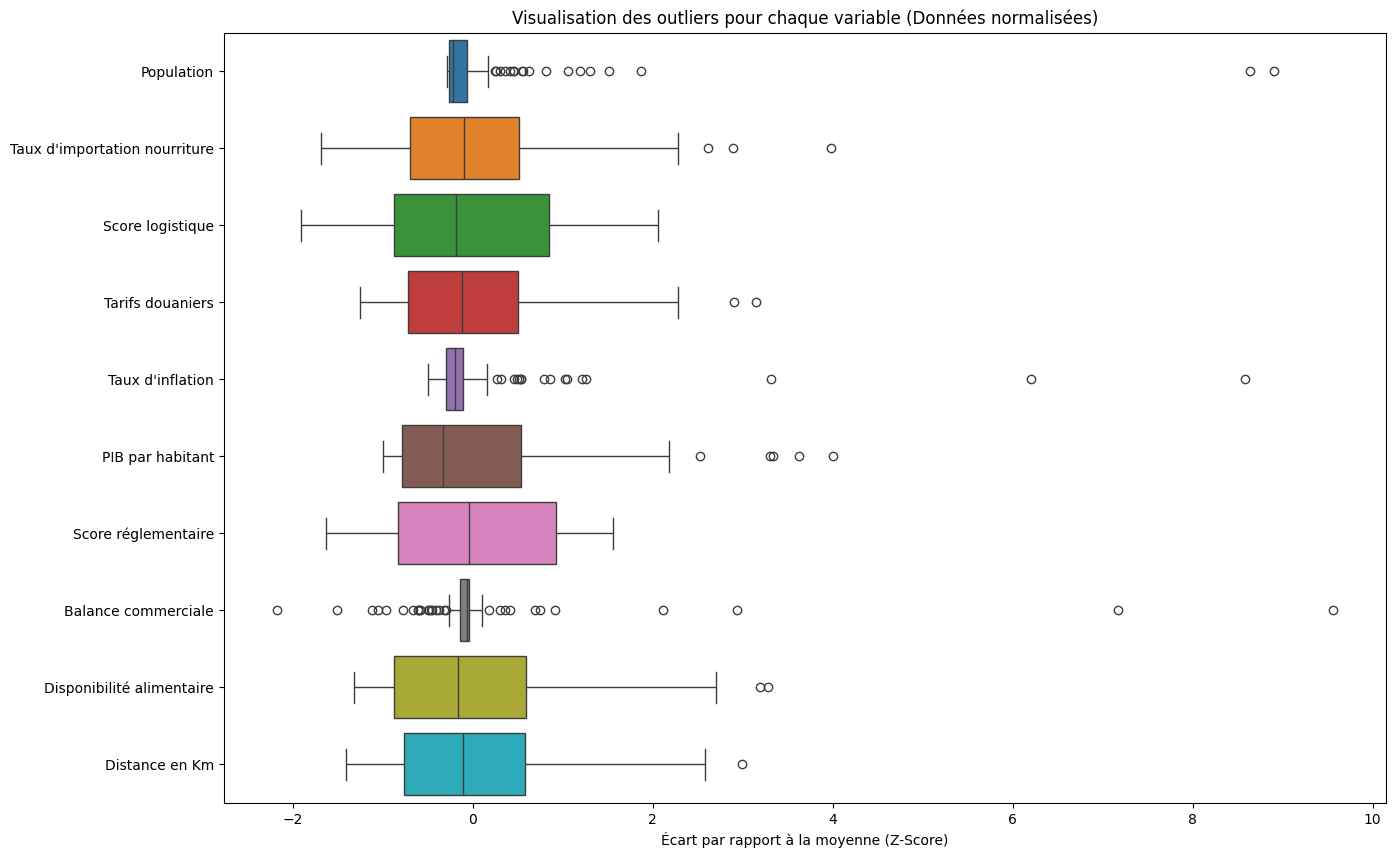

In [1130]:
plt.figure(figsize=(15, 10))
# Je crée un boxplot pour chaque colonne de métriques
df_numerique = merged_df[metric_columns]

# Je standardise les données pour le graphique (centrage et réduction)
df_norm = (df_numerique - df_numerique.mean()) / df_numerique.std()

# Affichage
sns.boxplot(data=df_norm, orient='h')
plt.title("Visualisation des outliers pour chaque variable (Données normalisées)")
plt.xlabel("Écart par rapport à la moyenne (Z-Score)")
plt.show()

In [1131]:
# J'affiche désormais la liste des pays outliers pour chaque variable
# On boucle sur chaque colonne
for col in metric_columns:
    Q1 = merged_df[col].quantile(0.25)
    Q3 = merged_df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Seuil standard (1.5)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Je filtre les données hors de nos deux bornes
    outliers = merged_df[(merged_df[col] < lower_bound) | (merged_df[col] > upper_bound)]

    # J'adapte l'affichage aux résultats
    if len(outliers) > 0:
        print(f"\n--- Outliers pour la colonne : {col} ---")
        # J'affiche le nom du pays et la valeur concernée, trié par grandeur
        print(outliers[['Country Name', col]].sort_values(by=col, ascending=False))
    else:
        print(f"\n--- Aucun outlier pour : {col} ---")


--- Outliers pour la colonne : Population ---
                         Country Name    Population
72                               Inde  1.450936e+09
34                Chine, continentale  1.408975e+09
51              États-Unis d'Amérique  3.401110e+08
73                          Indonésie  2.834879e+08
121                          Pakistan  2.512692e+08
114                           Nigéria  2.326795e+08
24                             Brésil  2.119986e+08
15                         Bangladesh  1.735624e+08
53               Fédération de Russie  1.435339e+08
52                           Éthiopie  1.320598e+08
103                           Mexique  1.308610e+08
44                             Égypte  1.165383e+08
127                       Philippines  1.158437e+08
135  République démocratique du Congo  1.092763e+08
171                          Viet Nam  1.009877e+08
74     Iran (République islamique d')  9.156774e+07
164                           Türkiye  8.551866e+07
4                

Il apparaît difficile de se passer de pays comme la Chine et l'Inde tant leur importance est grande en tant que puissance démographique et économique. Les chiffres montrent également des données très élevées pour la balance commerciale, les deux points les plus extrêmes sont le Brésil et les USA, difficile de se passer d'eux également.

Une première éxécution de l'ACP puis du clustering a conduit à un cluster composé de Liban et du Venezuela (pour un total de 3 clusters), ce qui n'est pas un résultat optimal. Même constat pour l'Argentine, dans un contexte de commerce internationale, des données d'inflation à ce niveau envoient un message négatif et sont le signe que ces pays ne sont pas des marchés porteurs et stables.

Au regard de leurs valeurs extrêmes pour la variable inflation, je supprime ces trois pays de mon dataframe.  
J'exlue également la France de mon jeu de données puisque c'est le pays de production de l'entreprise.

In [1132]:
# Liste des pays à exclure
blacklist = ['Venezuela (République bolivarienne du)', 'Liban', 'Argentine', 'France']

# Je filtre les pays qui ne sont pas dans la blacklist
merged_df = merged_df[~merged_df['Country Name'].isin(blacklist)]

print(f"Pays supprimés : {blacklist}")
print(f"Nombre de pays restants : {len(merged_df)}")


Pays supprimés : ['Venezuela (République bolivarienne du)', 'Liban', 'Argentine', 'France']
Nombre de pays restants : 171


## 3.3 Complétude des données

### 3.2.1 Filtrage des NaN et des pays de faible population

In [1133]:
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN,NaN,1.0,42647492.0,5500.6650
1,Afrique du Sud,33.95,-279.0,ZAF,ZA,Africa,Sub-Saharan Africa,Southern Africa,6.13,6.323338,3.7,10.8,13597.653850,4.0,64007187.0,8769.6790
2,Albanie,24.78,-52.0,ALB,AL,Europe,Southern Europe,NaN,4.75,16.077738,2.5,NaN,21641.053150,3.5,2714617.0,1499.4510
3,Algérie,9.88,0.0,DZA,DZ,Africa,Northern Africa,NaN,20.74,NaN,2.5,13.3,15501.919700,1.0,46814308.0,1233.8110
4,Allemagne,16.77,-170.0,DEU,DE,Europe,Western Europe,NaN,0.00,8.397362,4.1,12.2,62554.554723,4.5,83510950.0,789.5815


In [1134]:
# Je consulte le total des valeurs nulles dans chaque colonne
merged_df[metric_columns].isnull().sum()

,0
Population,0
Taux d'importation nourriture,34
Score logistique,45
Tarifs douaniers,43
Taux d'inflation,35
PIB par habitant,8
Score réglementaire,7
Balance commerciale,0
Disponibilité alimentaire,0
Distance en Km,6


In [1135]:
# Je rajoute une colonne pour comptabiliser le nombre de NaN pour chaque pays
merged_df['NaN_Count'] = merged_df[metric_columns].isnull().sum(axis=1)
# Je trie le df dans l'odre décroissant du nombre de NA trouvés pas lignes
merged_df = merged_df.sort_values(by='NaN_Count', ascending=False)

display(merged_df.head(15))
# Je contrôle la longueur
print(len(merged_df))

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km,NaN_Count
166,Tuvalu,54.20,0.0,TUV,TV,Oceania,Polynesia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9646.0,15684.160,6
116,Nouvelle-Calédonie,38.11,-10.0,NCL,NC,Oceania,Melanesia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,292639.0,16870.660,6
110,Nauru,53.35,-1.0,NRU,NR,Oceania,Micronesia,NaN,NaN,NaN,NaN,NaN,12468.761452,NaN,11947.0,14658.810,5
129,Polynésie française,51.71,-18.0,PYF,PF,Oceania,Polynesia,NaN,NaN,15.508033,NaN,NaN,NaN,NaN,281807.0,15922.950,5
165,Turkménistan,8.16,-39.0,TKM,TM,Asia,Central Asia,NaN,NaN,NaN,NaN,NaN,18662.298799,NaN,7494498.0,4587.559,5
70,Îles Marshall,74.21,-3.0,MHL,MH,Oceania,Micronesia,NaN,NaN,NaN,NaN,NaN,7209.266550,0.50,37548.0,13844.790,4
104,Micronésie (États fédérés de),37.62,-4.0,FSM,FM,Oceania,Micronesia,NaN,NaN,NaN,NaN,NaN,3824.152344,0.50,113160.0,13303.140,4
85,Kiribati,25.66,-2.0,KIR,KI,Oceania,Micronesia,NaN,NaN,NaN,NaN,NaN,3257.136291,1.00,134518.0,14609.770,4
0,Afghanistan,0.81,-5.0,AFG,AF,Asia,Southern Asia,NaN,NaN,NaN,1.9,NaN,NaN,1.00,42647492.0,5500.665,4
33,Chine - RAS de Macao,42.64,-34.0,MAC,MO,Asia,Eastern Asia,NaN,0.0,18.192496,NaN,NaN,111693.502831,NaN,687000.0,NaN,4


171


In [1136]:
# Je supprime les pays qui ont plus de 4 données manquantes, considérant qu'une réaffectation de valeurs pour ces lignes pourrait donner des résultats trop approximatifs
merged_df = merged_df[merged_df['NaN_Count'] < 4]

display(merged_df.head(15))

print(len(merged_df))

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km,NaN_Count
146,Sao Tomé-et-Principe,17.68,-3.0,STP,ST,Africa,Sub-Saharan Africa,Middle Africa,NaN,31.814850,NaN,NaN,5491.298299,0.50,235536.0,5172.648,3
91,Libye,31.28,-97.0,LBY,LY,Africa,Northern Africa,NaN,NaN,NaN,1.9,NaN,12583.833873,0.00,7381023.0,1989.087,3
148,Serbie,17.69,-17.0,SRB,RS,Europe,Southern Europe,NaN,NaN,NaN,2.8,18.1,26900.783403,4.50,6587202.0,NaN,3
143,Saint-Kitts-et-Nevis,62.97,-4.0,KNA,KN,Americas,Latin America and the Caribbean,Caribbean,NaN,NaN,NaN,5.0,30656.441011,0.00,46843.0,6771.986,3
142,Sainte-Lucie,64.39,-10.0,LCA,LC,Americas,Latin America and the Caribbean,Caribbean,NaN,NaN,NaN,6.5,24252.468859,2.00,179744.0,6916.219,3
123,Papouasie-Nouvelle-Guinée,3.97,-34.0,PNG,PG,Oceania,Melanesia,NaN,NaN,NaN,2.7,NaN,4288.528290,1.50,10576502.0,14488.950,3
135,République démocratique du Congo,0.76,-71.0,COD,CD,Africa,Sub-Saharan Africa,Middle Africa,NaN,4.767380,2.5,NaN,1602.074980,1.00,109276265.0,NaN,3
161,Tonga,87.93,-9.0,TON,TO,Oceania,Polynesia,NaN,8.44,NaN,NaN,10.4,NaN,1.75,104175.0,17137.600,3
169,Vanuatu,19.93,-6.0,VUT,VU,Oceania,Melanesia,NaN,12.90,NaN,NaN,NaN,3172.047728,0.00,327777.0,16443.900,3
50,Eswatini,4.55,-3.0,SWZ,SZ,Africa,Sub-Saharan Africa,Southern Africa,6.13,19.582639,NaN,NaN,10380.396663,1.00,1242822.0,8628.108,2


157


In [1137]:
# Je filtre les pays avec plus d'1 million d'habitants pour ne retenir que les états pouvant offrir des perspectives commerciales intéressantes
merged_df = merged_df[merged_df['Population'] > 1000000]

### 3.2.2 Complétude des données

In [1138]:
# Je consulte le total des valeurs nulles dans chaque colonne
merged_df[metric_columns].isnull().sum()

,0
Population,0
Taux d'importation nourriture,17
Score logistique,21
Tarifs douaniers,23
Taux d'inflation,13
PIB par habitant,0
Score réglementaire,0
Balance commerciale,0
Disponibilité alimentaire,0
Distance en Km,3


In [1139]:
# Je consulte pour une colonne donnée la liste des pays avec des valeurs NaN
merged_df.loc[merged_df["Taux d'importation nourriture"].isnull(), ['Country Name', 'Region Name', "Sub-region Name", "Taux d'importation nourriture"]]

,Country Name,Region Name,Sub-region Name,Taux d'importation nourriture
91,Libye,Africa,Northern Africa,NaN
148,Serbie,Europe,Southern Europe,NaN
123,Papouasie-Nouvelle-Guinée,Oceania,Melanesia,NaN
53,Fédération de Russie,Europe,Eastern Europe,NaN
67,Haïti,Americas,Latin America and the Caribbean,NaN
74,Iran (République islamique d'),Asia,Southern Asia,NaN
75,Iraq,Asia,Western Asia,NaN
17,Bélarus,Europe,Eastern Europe,NaN
150,Sierra Leone,Africa,Sub-Saharan Africa,NaN
111,Népal,Asia,Southern Asia,NaN


In [1140]:
# 1. On crée une COPIE de travail temporaire
# Cela protège votre 'merged_df' original
df_to_fill = merged_df.copy()

# 2. On effectue les calculs sur cette COPIE (df_analyse)
# Pour la REGION
df_to_fill['Region_Nb_Pays'] = df_to_fill.groupby('Region Name')['Country Name'].transform('count')
df_to_fill['Region_Moyenne'] = df_to_fill.groupby('Region Name')["Taux d'importation nourriture"].transform('mean')
df_to_fill['Region_Mediane'] = df_to_fill.groupby('Region Name')["Taux d'importation nourriture"].transform('median')

# Pour la SOUS-REGION
df_to_fill['SubReg_Nb_Pays'] = df_to_fill.groupby('Sub-region Name')['Country Name'].transform('count')
df_to_fill['SubReg_Moyenne'] = df_to_fill.groupby('Sub-region Name')["Taux d'importation nourriture"].transform('mean')
df_to_fill['SubReg_Mediane'] = df_to_fill.groupby('Sub-region Name')["Taux d'importation nourriture"].transform('median')

# 3. On définit les colonnes à afficher
cols_a_afficher = [
    'Country Name',
    'Region Name',
    'Region_Nb_Pays', 'Region_Moyenne', 'Region_Mediane',
    'Sub-region Name',
    'SubReg_Nb_Pays', 'SubReg_Moyenne', 'SubReg_Mediane'
]

# 4. On filtre pour voir les résultats
df_missing_context = df_to_fill.loc[df_to_fill["Taux d'importation nourriture"].isnull(), cols_a_afficher]

# Affichage
display(df_missing_context)

# À la fin de cette cellule, 'merged_df' est resté propre (sans les colonnes ajoutées),
# mais vous avez pu visualiser les infos nécessaires pour prendre vos décisions.

,Country Name,Region Name,Region_Nb_Pays,Region_Moyenne,Region_Mediane,Sub-region Name,SubReg_Nb_Pays,SubReg_Moyenne,SubReg_Mediane
91,Libye,Africa,39,15.897557,15.080085,Northern Africa,5,16.354344,13.977771
148,Serbie,Europe,34,10.953356,10.617950,Southern Europe,10,12.602062,12.252844
123,Papouasie-Nouvelle-Guinée,Oceania,3,8.695478,8.695478,Melanesia,1,NaN,NaN
53,Fédération de Russie,Europe,34,10.953356,10.617950,Eastern Europe,10,9.580502,9.917881
67,Haïti,Americas,21,13.121736,13.460810,Latin America and the Caribbean,19,13.732785,14.016134
74,Iran (République islamique d'),Asia,36,11.510297,11.444750,Southern Asia,6,12.054673,15.354160
75,Iraq,Asia,36,11.510297,11.444750,Western Asia,14,12.435987,13.401093
17,Bélarus,Europe,34,10.953356,10.617950,Eastern Europe,10,9.580502,9.917881
150,Sierra Leone,Africa,39,15.897557,15.080085,Sub-Saharan Africa,34,15.850303,15.715778
111,Népal,Asia,36,11.510297,11.444750,Southern Asia,6,12.054673,15.354160


Ce tableau permet de voir les différences entre régions et sous régions. La moyenne est trop influencée par les potentielles valeurs hautes de la distribution, je vais opter pour la médiane. Pour assurer le plus de précision possible, je choisirai la médiane de la sous-région.

Ce n'est pas possibe pour la Papouasie-Nouvelle-Guinée qui est seule dans sa sous-région, la médiane retenue sera celle de la région.


In [1141]:
# Je rajoute un seuil de fiabilité : un nombre minimum de pays requis pour faire confiance aux données de la sous-région
MIN_PAYS = 3

for col in metric_columns:
    # Calculs par Sous_région
    # Je calcule la médiane
    sub_median = merged_df.groupby('Sub-region Name')[col].transform('median')
    # Je compte le nombre de pays de cette sous-région
    sub_count = merged_df.groupby('Sub-region Name')[col].transform('count')

    # Je rajoute les conditions de filtres
    # Si le nombre de pays est inférieure à 3, je ne retiens pas la médiane de la sous-région (réimputation de NaN)
    sub_median = sub_median.where(sub_count >= MIN_PAYS, np.nan)

    # Calcul par Région
    region_median = merged_df.groupby('Region Name')[col].transform('median')

    # Application en cascade
    # Priorité 1 : Sous-région (uniquement si fiable, grâce à l'étape 2)
    merged_df[col] = merged_df[col].fillna(sub_median)

    # Priorité 2 : Région (Si la sous-région était vide OU jugée non fiable)
    merged_df[col] = merged_df[col].fillna(region_median)

In [1142]:
merged_df[metric_columns].isnull().sum()

,0
Population,0
Taux d'importation nourriture,0
Score logistique,0
Tarifs douaniers,0
Taux d'inflation,0
PIB par habitant,0
Score réglementaire,0
Balance commerciale,0
Disponibilité alimentaire,0
Distance en Km,0


In [1143]:
# Je supprime la colonne devenue inutile
merged_df = merged_df.drop(columns=['NaN_Count'])

In [1144]:
len(merged_df)

133

## 3.4 Observation des ordres de grandeur

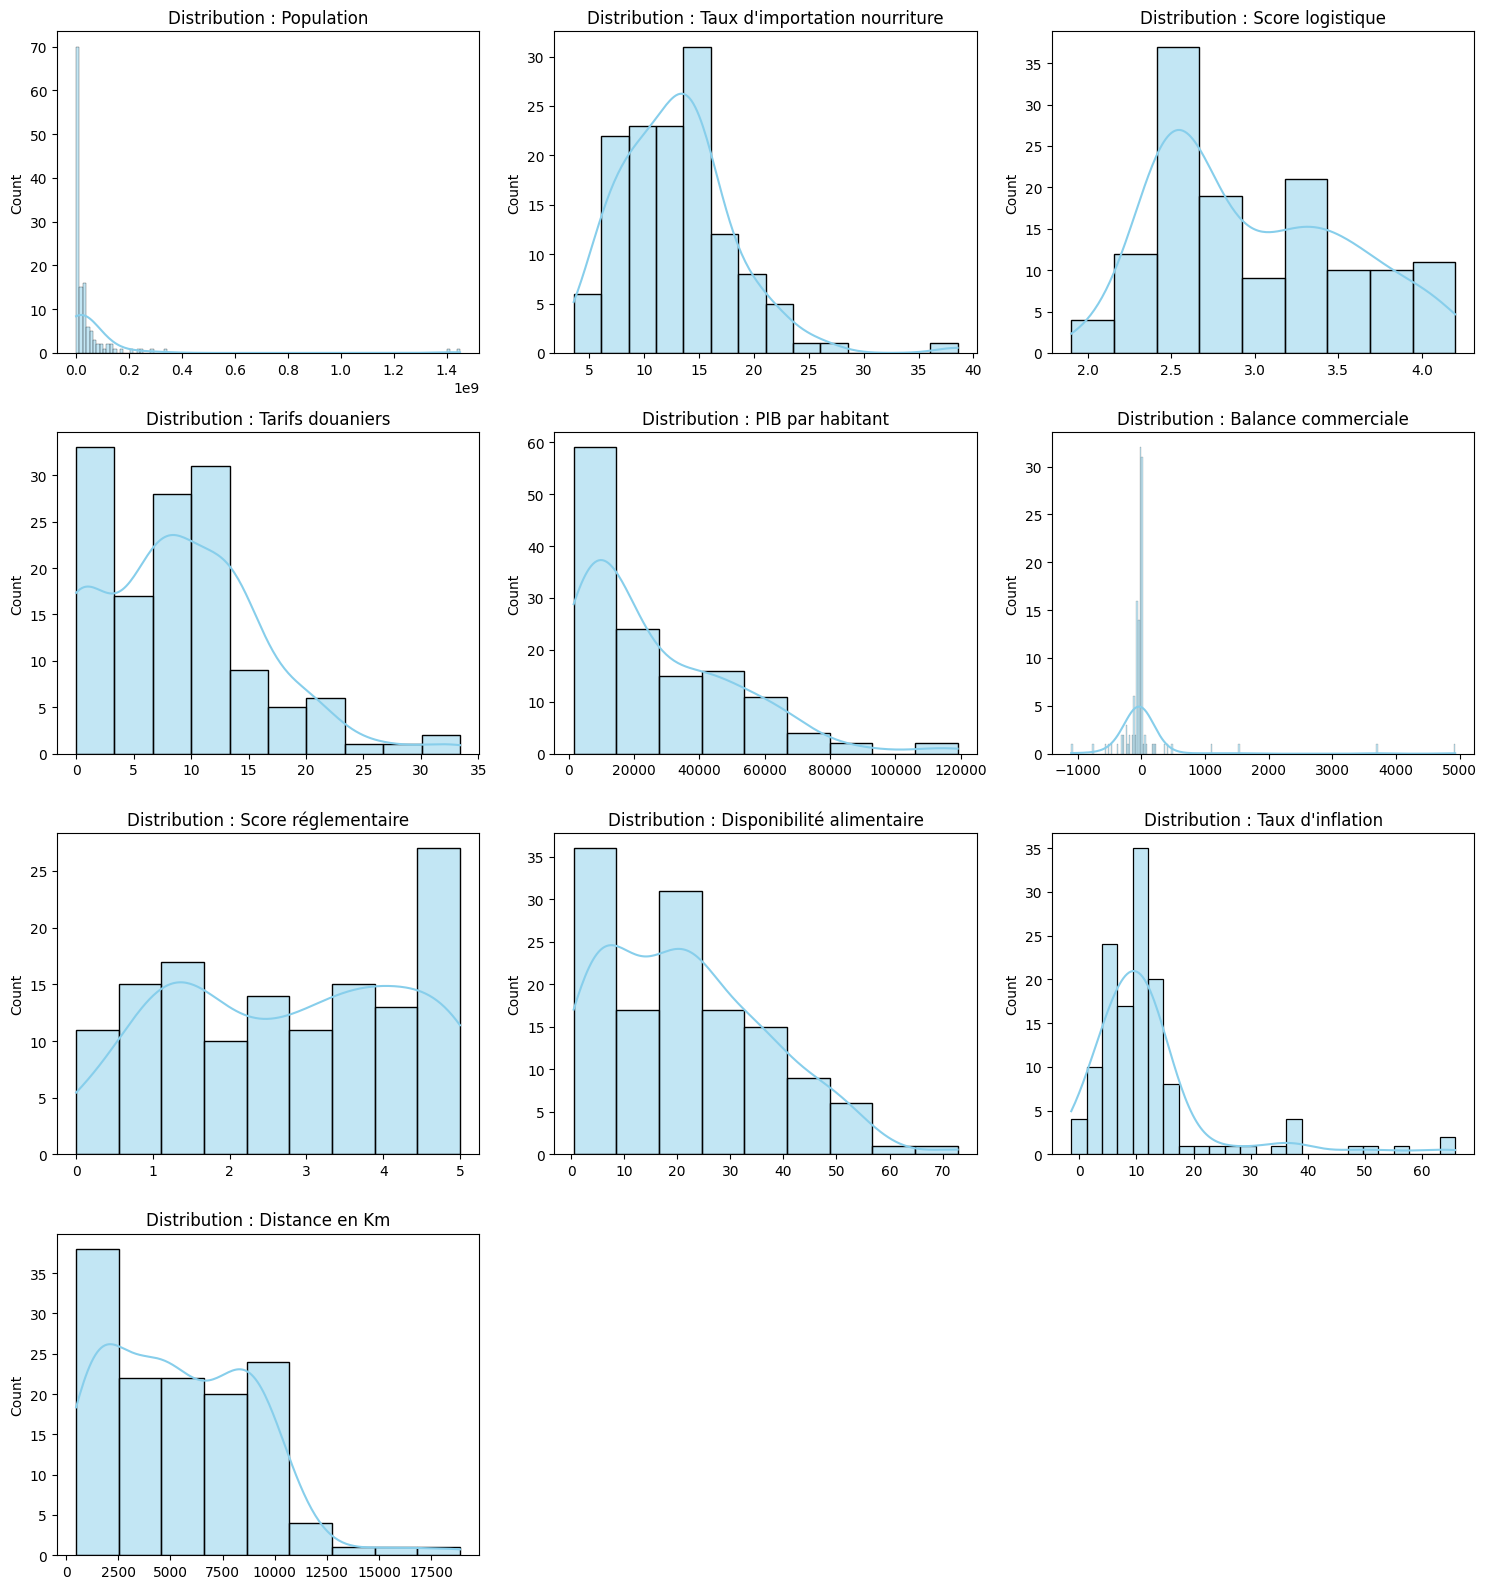

In [1145]:
# J'extrais les colonnes pour l'analyse
cols = ["Population","Taux d'importation nourriture","Score logistique","Tarifs douaniers","PIB par habitant","Balance commerciale","Score réglementaire","Disponibilité alimentaire", "Taux d'inflation", "Distance en Km"]

# Configuration de la figure
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    # On trace l'histogramme avec la courbe de densité (kde=True)
    sns.histplot(merged_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution : {col}")
    axes[i].set_xlabel("")

for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Explication de ce pré-traitement de transformation logarithmique

Avant de réaliser l'ACP, j'ai constaté une forte asymétrie positive sur la variable Population, cette variable ne suit pas ue forme normale dans sa distribution.
Cela est dû aux populations de la Chine et l'Inde (cf 3.2 Outliers).

Bien que l'ACP nécessité dans son processus de standardiser les variables (centrage-réduction) pour neutraliser les différences d'unités, cette étape ne corrige pas l'asymétrie des distributions.

Le traitement logarithmique va réduire le poids des valeurs extrêmes sans supprimer l'information structurelle du jeu de données.

In [1146]:
# On applique le log sur la Population et le PIB par habitant
# np.log10 transforme "1 milliard" (9 zéros) en "9". C'est beaucoup plus digeste pour l'ACP.

# Transformation de la Population et du PIB par habitant
merged_df['Population_Log'] = np.log10(merged_df['Population'])

merged_df['PIB_Log'] = np.log10(merged_df['PIB par habitant'])



In [1147]:
cols_finales = [
    "Population_Log",
    "PIB_Log",
    "Taux d'inflation",
    "Distance en Km",
    "Taux d'importation nourriture",
    "Score logistique",
    "Tarifs douaniers",
    "Balance commerciale",
    "Score réglementaire",
    "Disponibilité alimentaire"
]

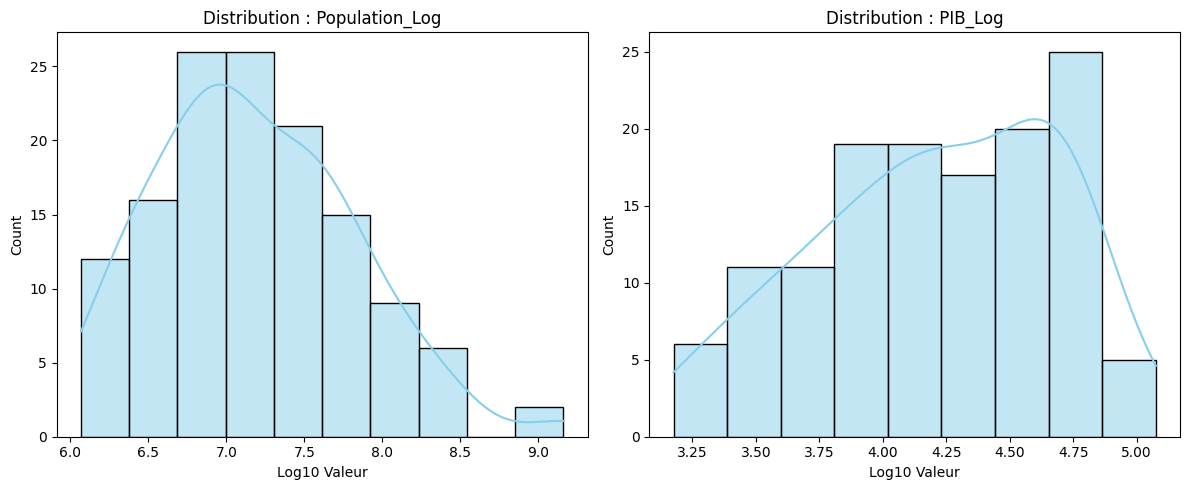

In [1148]:
# Je vérifie les modifications opérées sur les formes de distribution
# Je conserve uniquement les deux colonnes log
cols_log = ['Population_Log', 'PIB_Log']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(cols_log):
    sns.histplot(merged_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution : {col}")
    axes[i].set_xlabel("Log10 Valeur")

plt.tight_layout()
plt.show()

In [1149]:
merged_df.head()

,Country Name,Disponibilité alimentaire,Balance commerciale,Country Code,ISO-alpha2 Code,Region Name,Sub-region Name,Intermediate Region Name,Tarifs douaniers,Taux d'importation nourriture,Score logistique,Taux d'inflation,PIB par habitant,Score réglementaire,Population,Distance en Km,Population_Log,PIB_Log
91,Libye,31.28,-97.0,LBY,LY,Africa,Northern Africa,NaN,13.29,13.977771,1.9,13.85,12583.833873,0.0,7381023.0,1989.087,6.868117,4.099813
148,Serbie,17.69,-17.0,SRB,RS,Europe,Southern Europe,NaN,0.00,12.252844,2.8,18.10,26900.783403,4.5,6587202.0,1226.467,6.818701,4.429765
123,Papouasie-Nouvelle-Guinée,3.97,-34.0,PNG,PG,Oceania,Melanesia,NaN,1.01,8.695478,2.7,8.25,4288.528290,1.5,10576502.0,14488.950,7.024342,3.632308
135,République démocratique du Congo,0.76,-71.0,COD,CD,Africa,Sub-Saharan Africa,Middle Africa,13.29,4.767380,2.5,10.85,1602.074980,1.0,109276265.0,5762.769,8.038526,3.204683
50,Eswatini,4.55,-3.0,SWZ,SZ,Africa,Sub-Saharan Africa,Southern Africa,6.13,19.582639,2.5,10.85,10380.396663,1.0,1242822.0,8628.108,6.094409,4.016214


Vérifications des deux contraintes : plus de 100 pays, et représentant 60 % de la population.

In [1150]:
# On vérifie la longueur actuelle
print(f"Nombre de pays restants : {len(merged_df)}")

# Si on a moins de 100 pays, c'est anormal -> On arrête tout avec une erreur
if len(merged_df) < 100:
    # Le message doit expliquer pourquoi ça a planté
    raise ValueError(f"Alerte : Le DataFrame ne contient que {len(merged_df)} pays (moins de 100) !")

else:
    # Si on est au-dessus de 100, tout va bien
    print("Contrainte remplie : Le DataFrame contient bien plus de 100 pays.")

Nombre de pays restants : 133
Contrainte remplie : Le DataFrame contient bien plus de 100 pays.


In [1151]:
population_df = merged_df['Population'].sum()
population_totale = population['2024'].sum() # Assurez-vous que ce DF 'population' existe toujours
part_population = (population_df / population_totale) * 100

# J'affiche la population totale
print(f"Population totale (base originale) : {population_totale:,.0f}")

# Je vérifie la contrainte
if part_population < 60:
    raise ValueError(f"Alerte : Les pays du dataframe ne représentent que {part_population:.2f}% de la population (inférieur à 60%)")
else:
    print(f"Contrainte remplie : les pays du dataframe représentent {part_population:.2f}% de la population totale.")

Population totale (base originale) : 8,116,948,097
Contrainte remplie : les pays du dataframe représentent 92.23% de la population totale.


Export

In [1152]:
output_path = '/content/drive/MyDrive/Data Analyst/Module 11/df_data.csv'
merged_df.to_csv(output_path, index=False)
print(f'DataFrame exported successfully to {output_path}')

DataFrame exported successfully to /content/drive/MyDrive/Data Analyst/Module 11/df_data.csv
